In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (4000, 28)


In [ ]:
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(i, "-", col)

Column Names:
1 - Farm_ID
2 - State
3 - District
4 - Crop
5 - Season
6 - Farm_Area_Hectares
7 - Rainfall_mm
8 - Avg_Temperature_C
9 - Humidity_pct
10 - Sunlight_Hours_Day
11 - Soil_pH
12 - Soil_Moisture_pct
13 - Nitrogen_kg_ha
14 - Phosphorus_kg_ha
15 - Potassium_kg_ha
16 - Irrigation_Method
17 - Fertilizer_kg_ha
18 - Pesticide_Litre_ha
19 - Seed_Quality_Score
20 - Yield_Tonnes_Ha
21 - Production_Tonnes
22 - Market_Price_INR_Tonne
23 - Total_Cost_INR
24 - Revenue_INR
25 - Profit_INR
26 - Water_Used_m3
27 - Water_Efficiency_t_per_1000m3
28 - Disease_Pest_Risk_pct


In [ ]:
print(" DATASET INFORMATION ")
df.info()

print("\n MISSING VALUES ")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("\n DUPLICATE ROWS ")
print("Number of duplicate rows:", df.duplicated().sum())

 DATASET INFORMATION 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha            

In [ ]:
# Handle missing values using median

df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())

df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [ ]:
print(" CLEANED DATASET SUMMARY ")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nFirst 5 rows:")
display(df.head())

 CLEANED DATASET SUMMARY 
Rows: 4000
Columns: 28

Missing values: 0
Duplicate rows: 0

First 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
# Explore categorical variables

categorical_columns = [
    'State',
    'District',
    'Crop',
    'Season',
    'Irrigation_Method'
]

for col in categorical_columns:
    print("\n==============================")
    print(col)
    print("==============================")
    print("Number of unique values:", df[col].nunique())
    print(df[col].value_counts())


State
Number of unique values: 8
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
Number of unique values: 10
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Number of unique values: 8
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season
Number of unique values: 3
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method
Number of unique values: 4
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


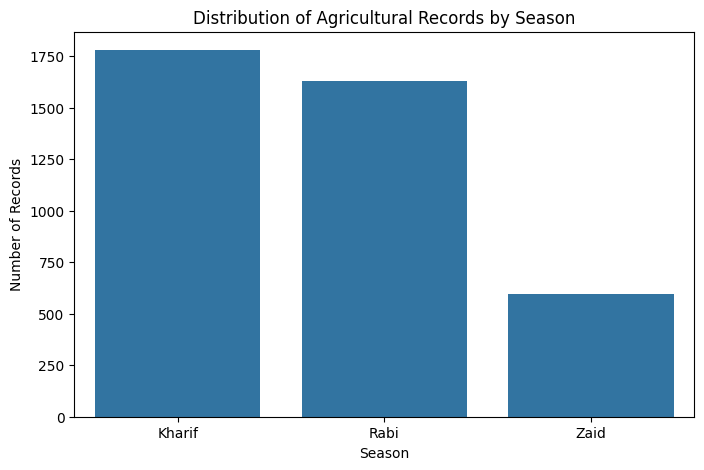

In [ ]:
# Season-wise distribution

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Season')

plt.title('Distribution of Agricultural Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')

plt.show()

Average Yield by Season:
Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


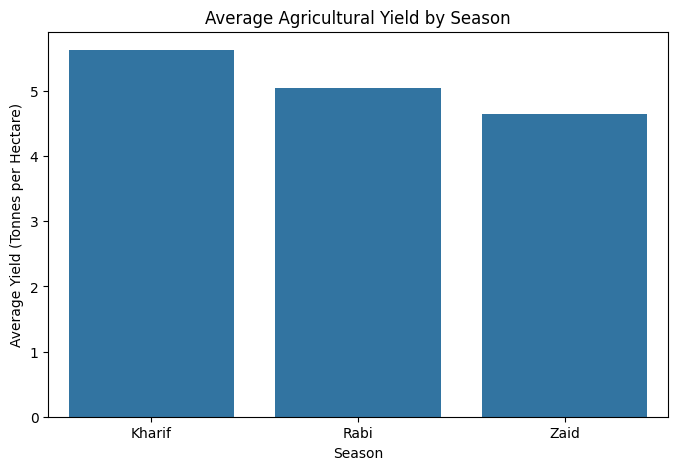

In [ ]:
# Average yield by season

season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print("Average Yield by Season:")
print(season_yield)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)

plt.title('Average Agricultural Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes per Hectare)')

plt.show()

Total Production by Season:
Season
Kharif    82387.61
Rabi      67498.88
Zaid      23098.35
Name: Production_Tonnes, dtype: float64


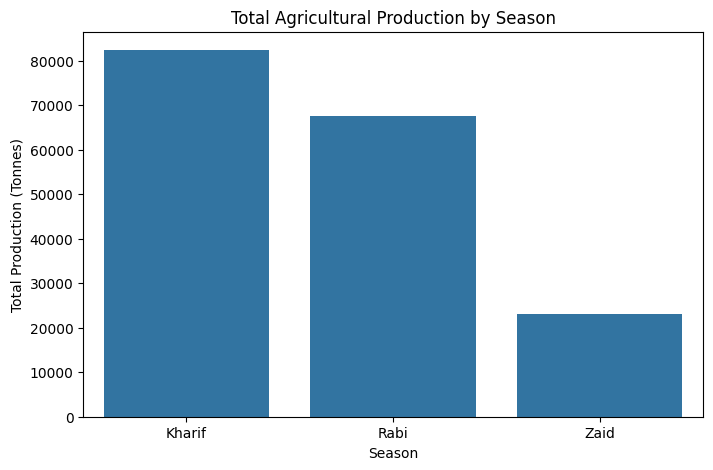

In [ ]:
# Total production by season

season_production = df.groupby('Season')['Production_Tonnes'].sum().sort_values(ascending=False)

print("Total Production by Season:")
print(season_production)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_production.index,
    y=season_production.values
)

plt.title('Total Agricultural Production by Season')
plt.xlabel('Season')
plt.ylabel('Total Production (Tonnes)')

plt.show()

Average Profit by Season:
Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


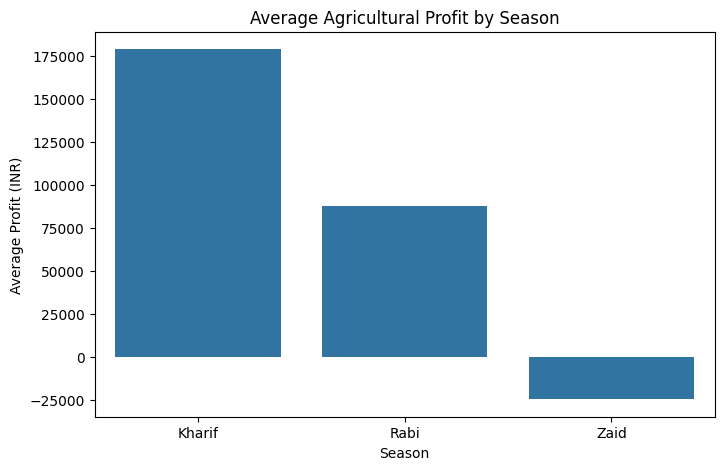

In [ ]:
# Average profit by season

season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

print("Average Profit by Season:")
print(season_profit)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_profit.index,
    y=season_profit.values
)

plt.title('Average Agricultural Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

Average Yield by Crop:
Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64


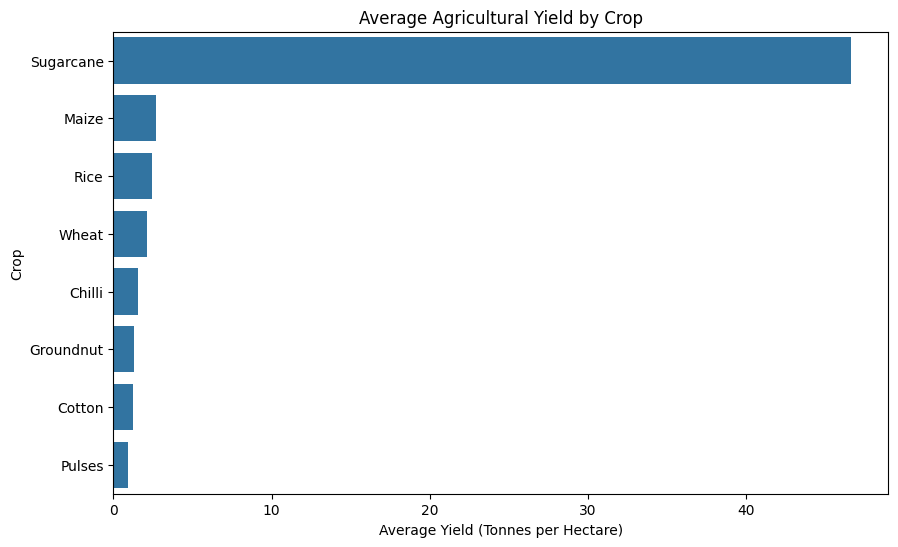

In [ ]:
# Average yield by crop

crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print("Average Yield by Crop:")
print(crop_yield)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_yield.values,
    y=crop_yield.index
)

plt.title('Average Agricultural Yield by Crop')
plt.xlabel('Average Yield (Tonnes per Hectare)')
plt.ylabel('Crop')

plt.show()

Average Profit by Crop:
Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64


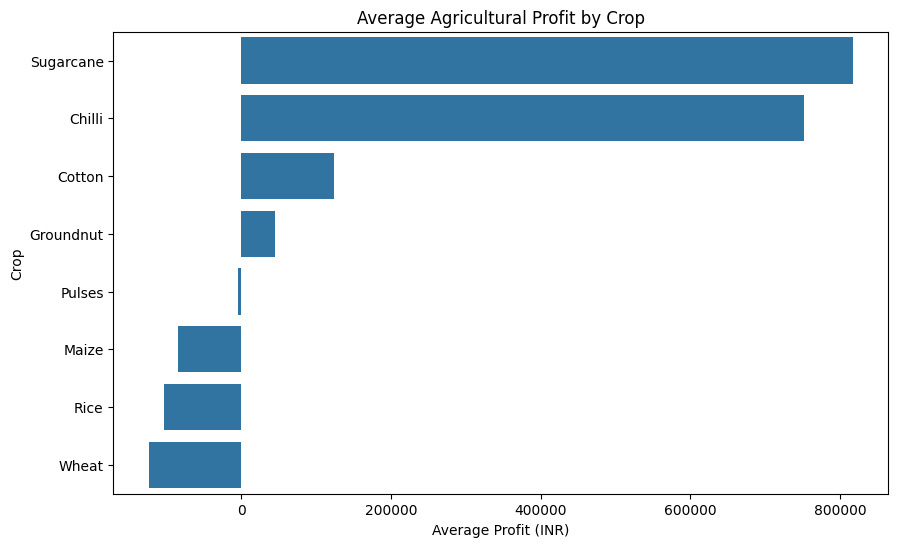

In [ ]:
# Average profit by crop

crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

print("Average Profit by Crop:")
print(crop_profit)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_profit.values,
    y=crop_profit.index
)

plt.title('Average Agricultural Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')

plt.show()

Average Water Usage by Irrigation Method:
Irrigation_Method
Flood        8026.472519
Sprinkler    6208.258856
Drip         5918.747541
Rainfed      3549.554275
Name: Water_Used_m3, dtype: float64


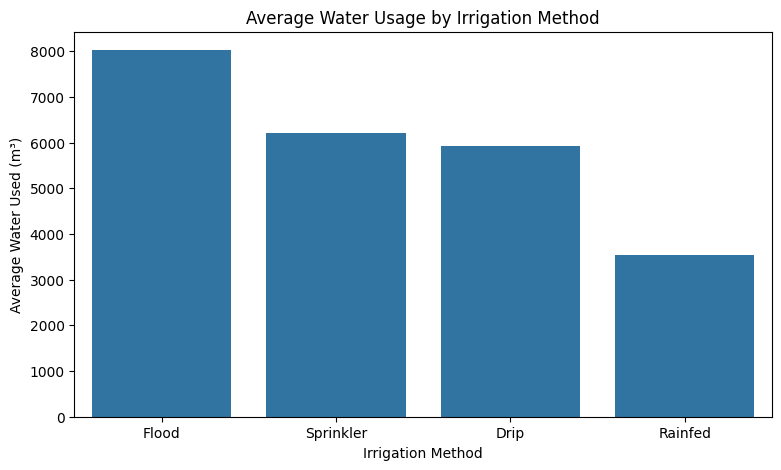

In [ ]:
# Average water usage by irrigation method

irrigation_water = (
    df.groupby('Irrigation_Method')['Water_Used_m3']
    .mean()
    .sort_values(ascending=False)
)

print("Average Water Usage by Irrigation Method:")
print(irrigation_water)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=irrigation_water.index,
    y=irrigation_water.values
)

plt.title('Average Water Usage by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Water Used (m³)')

plt.show()

Average Water Efficiency by Irrigation Method:
Irrigation_Method
Rainfed      7.563784
Drip         6.267129
Sprinkler    4.669805
Flood        3.438853
Name: Water_Efficiency_t_per_1000m3, dtype: float64


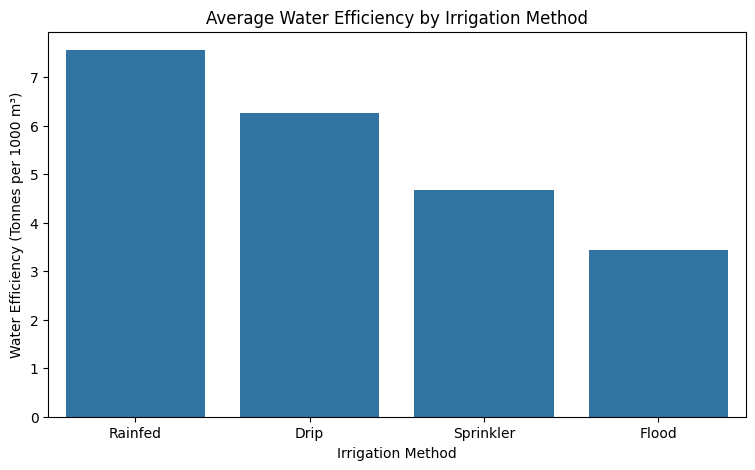

In [ ]:
# Average water efficiency by irrigation method

irrigation_efficiency = (
    df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3']
    .mean()
    .sort_values(ascending=False)
)

print("Average Water Efficiency by Irrigation Method:")
print(irrigation_efficiency)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=irrigation_efficiency.index,
    y=irrigation_efficiency.values
)

plt.title('Average Water Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')

plt.show()

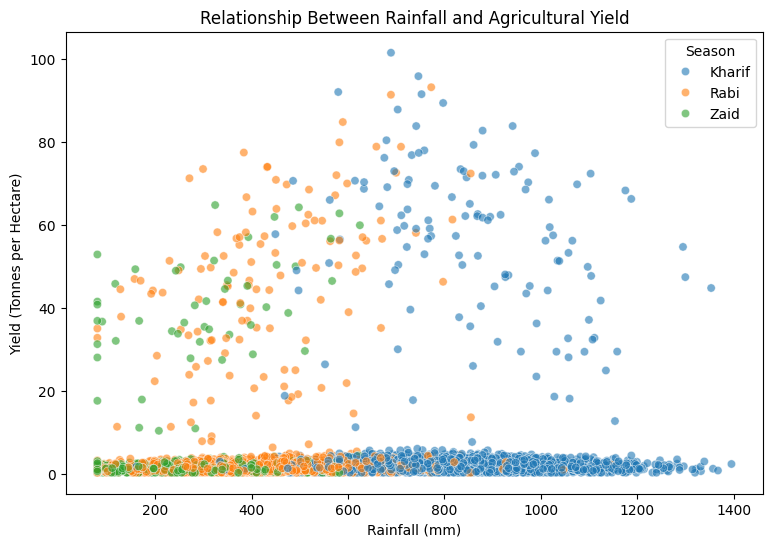

In [ ]:
# Relationship between rainfall and yield

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.6
)

plt.title('Relationship Between Rainfall and Agricultural Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.show()

In [ ]:
# Correlation between rainfall and yield

rainfall_yield_corr = df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha'])

print("Correlation between Rainfall and Yield:")
print(round(rainfall_yield_corr, 3))

Correlation between Rainfall and Yield:
0.031


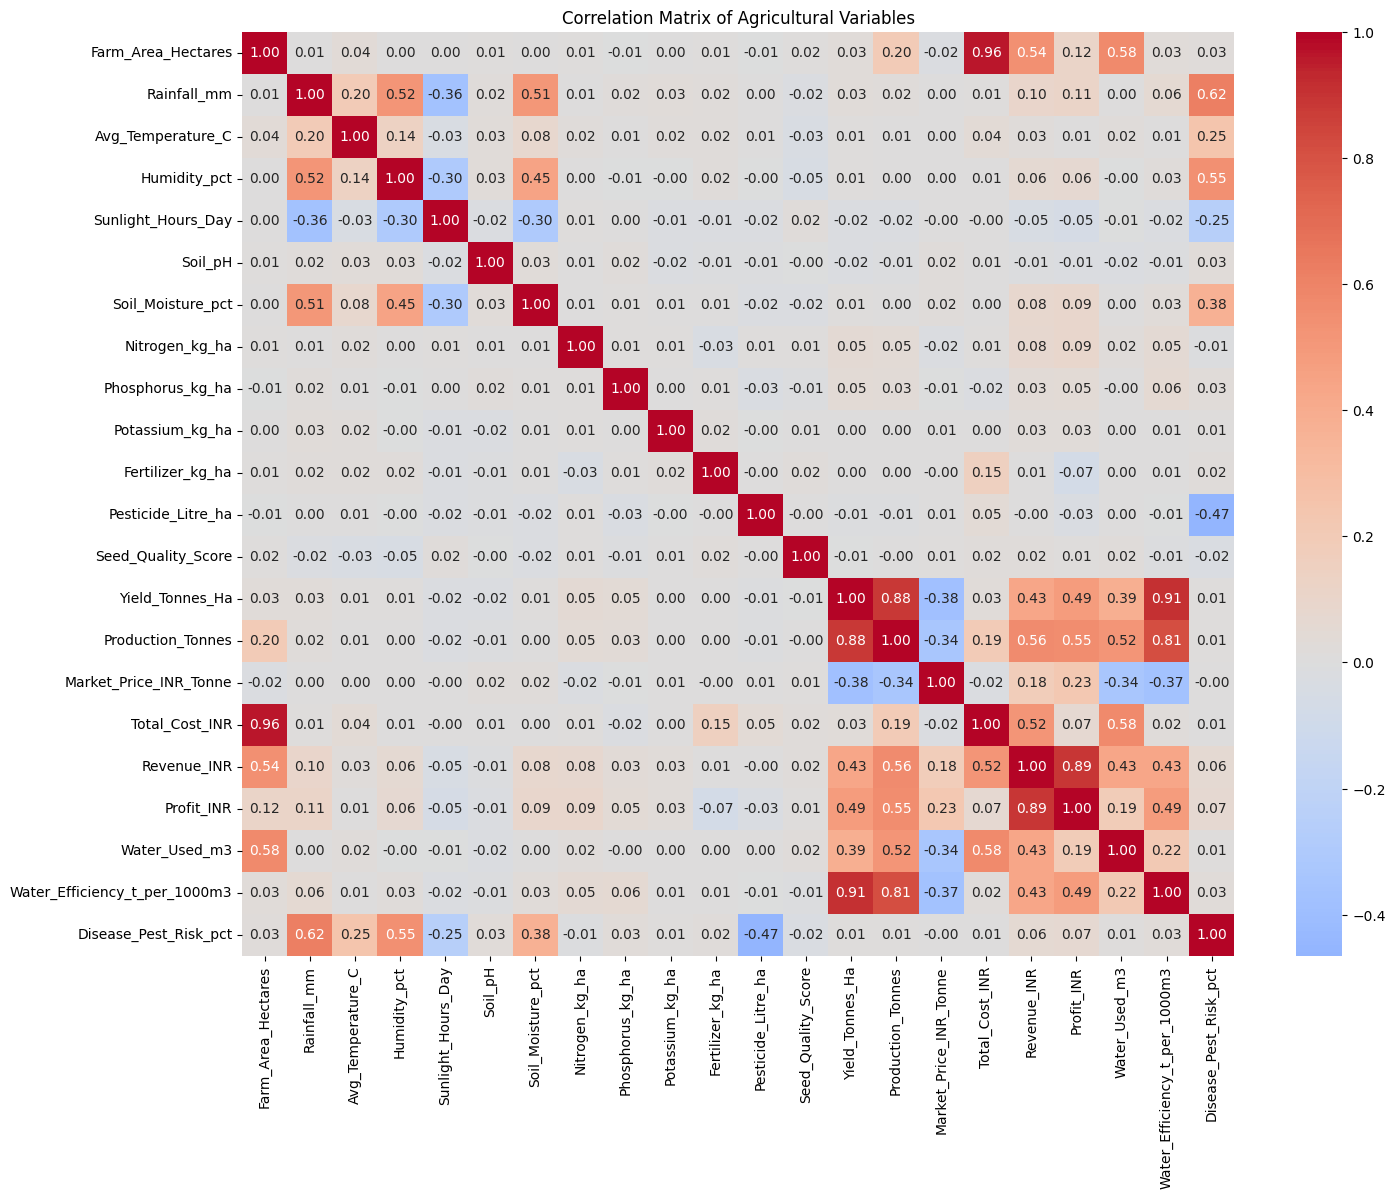

In [ ]:
# Correlation analysis of numerical variables

numeric_columns = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Agricultural Variables')
plt.show()

In [ ]:
# Check important numerical variables

print("Average values of important variables:\n")

important_columns = [
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3'
]

display(df[important_columns].describe().T)

Average values of important variables:



,count,mean,std,min,25%,50%,75%,max
Yield_Tonnes_Ha,4000.0,5.242350,13.311549,0.300,1.050,1.7400,2.83000,101.44
Production_Tonnes,4000.0,43.246210,126.880521,0.150,5.020,11.7700,24.35500,1424.40
Market_Price_INR_Tonne,4000.0,44714.166250,30266.161922,2594.000,21429.250,25913.0000,68279.00000,131240.00
Total_Cost_INR,4000.0,526303.583000,294419.140911,26826.000,274577.500,519082.5000,761996.50000,1349990.00
Revenue_INR,4000.0,637860.048000,636974.710054,6107.000,207517.250,456830.5000,836874.75000,5080900.00
Profit_INR,4000.0,111556.465000,545081.890509,-1019223.000,-148731.750,3673.0000,216187.75000,4345421.00
Water_Used_m3,4000.0,6045.570250,5572.944306,128.000,2268.750,4435.0000,7829.75000,40902.00
Water_Efficiency_t_per_1000m3,4000.0,5.385214,8.838101,0.135,1.661,2.9375,5.15025,79.80


In [ ]:
# Check relationships between calculated variables

# Revenue should approximately equal Production × Market Price
calculated_revenue = (
    df['Production_Tonnes'] * df['Market_Price_INR_Tonne']
)

revenue_difference = (
    df['Revenue_INR'] - calculated_revenue
).abs()

# Profit should approximately equal Revenue - Total Cost
calculated_profit = (
    df['Revenue_INR'] - df['Total_Cost_INR']
)

profit_difference = (
    df['Profit_INR'] - calculated_profit
).abs()

# Water efficiency should approximately relate Yield and Water Used
calculated_efficiency = (
    df['Yield_Tonnes_Ha'] / df['Water_Used_m3'] * 1000
)

efficiency_difference = (
    df['Water_Efficiency_t_per_1000m3'] - calculated_efficiency
).abs()

print("Maximum Revenue calculation difference:",
      revenue_difference.max())

print("Maximum Profit calculation difference:",
      profit_difference.max())

print("Maximum Water Efficiency calculation difference:",
      efficiency_difference.max())

Maximum Revenue calculation difference: 0.5
Maximum Profit calculation difference: 0
Maximum Water Efficiency calculation difference: 71.0735913166588


In [ ]:
# Test possible formulas for Water Efficiency

# Formula 1: Yield / Water Used × 1000
efficiency_from_yield = (
    df['Yield_Tonnes_Ha'] / df['Water_Used_m3'] * 1000
)

# Formula 2: Production / Water Used × 1000
efficiency_from_production = (
    df['Production_Tonnes'] / df['Water_Used_m3'] * 1000
)

print("Actual Water Efficiency - Mean:",
      round(df['Water_Efficiency_t_per_1000m3'].mean(), 3))

print("\nCalculated using Yield - Mean:",
      round(efficiency_from_yield.mean(), 3))

print("Calculated using Production - Mean:",
      round(efficiency_from_production.mean(), 3))

print("\nCorrelation with Yield:",
      round(df['Water_Efficiency_t_per_1000m3'].corr(df['Yield_Tonnes_Ha']), 3))

print("Correlation with Production:",
      round(df['Water_Efficiency_t_per_1000m3'].corr(df['Production_Tonnes']), 3))

Actual Water Efficiency - Mean: 5.385

Calculated using Yield - Mean: 1.194
Calculated using Production - Mean: 5.385

Correlation with Yield: 0.913
Correlation with Production: 0.812


Average Profit by Crop and Season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,9.543804e+05,638572.496933,448659.093750
Cotton,2.169995e+05,107343.587065,-53925.336957
Groundnut,1.082654e+05,10416.542373,-68872.500000
Maize,-3.933267e+04,-89133.403433,-194049.166667
Pulses,4.333890e+04,-14309.136150,-139227.806452
Rice,-6.490340e+04,-98427.868613,-227239.343137
Sugarcane,1.000791e+06,731612.860465,583635.803922
Wheat,-1.058719e+05,-119954.565401,-193208.952941


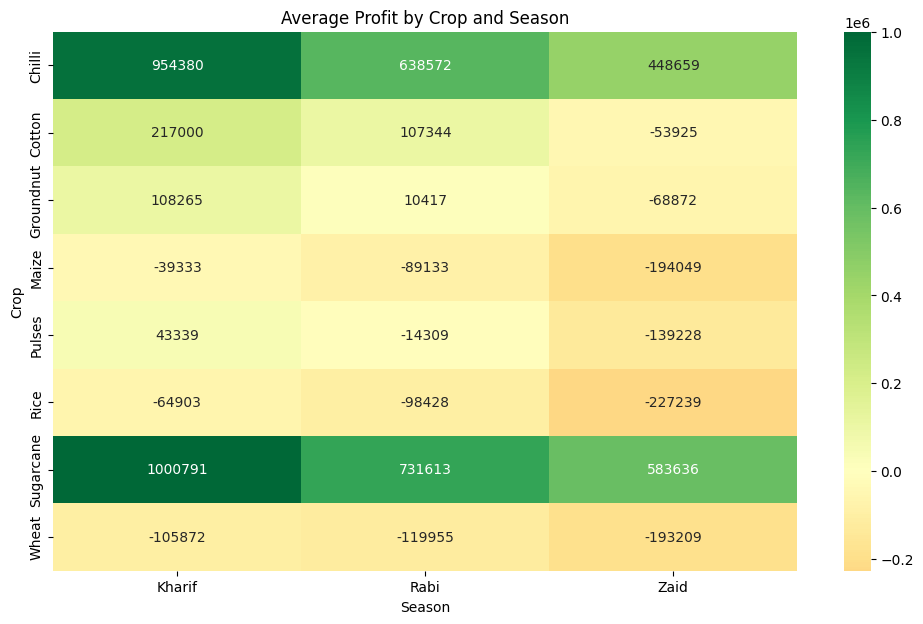

In [ ]:
# Average profit by crop and season

crop_season_profit = df.pivot_table(
    values='Profit_INR',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

print("Average Profit by Crop and Season:")
display(crop_season_profit)

plt.figure(figsize=(12, 7))

sns.heatmap(
    crop_season_profit,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0
)

plt.title('Average Profit by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

In [ ]:
# Environmental conditions by season

environmental_by_season = df.groupby('Season')[
    [
        'Rainfall_mm',
        'Avg_Temperature_C',
        'Humidity_pct',
        'Sunlight_Hours_Day',
        'Soil_Moisture_pct'
    ]
].mean()

print("Average Environmental Conditions by Season:")
display(environmental_by_season.round(2))

Average Environmental Conditions by Season:


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


In [ ]:
# Resource usage by season

resource_by_season = df.groupby('Season')[
    [
        'Water_Used_m3',
        'Fertilizer_kg_ha',
        'Pesticide_Litre_ha'
    ]
].mean()

print("Average Resource Usage by Season:")
display(resource_by_season.round(2))

Average Resource Usage by Season:


,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,
Kharif,6102.20,187.08,5.08
Rabi,5846.99,185.41,5.02
Zaid,6419.89,184.64,5.17


In [ ]:
# Economic outcomes by season

economic_by_season = df.groupby('Season')[
    [
        'Revenue_INR',
        'Total_Cost_INR',
        'Profit_INR'
    ]
].mean()

print("Average Economic Outcomes by Season:")
display(economic_by_season.round(2))

Average Economic Outcomes by Season:


,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.06,531804.41,178914.65
Rabi,601526.05,513836.58,87689.47
Zaid,519171.90,543976.73,-24804.82


In [ ]:
# Average profit by State and Season

state_season_profit = df.pivot_table(
    values='Profit_INR',
    index='State',
    columns='Season',
    aggfunc='mean'
)

print("Average Profit by State and Season:")
display(state_season_profit.round(2))

Average Profit by State and Season:


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.52,26315.71,-84084.87
Gujarat,217051.33,82846.20,-106929.61
Karnataka,201226.21,70952.61,23310.91
Madhya Pradesh,134242.40,61576.26,209.70
Maharashtra,168801.05,159581.50,-40597.60
Punjab,133779.10,169294.52,62109.69
Tamil Nadu,211303.96,70456.86,-15175.20
Telangana,199668.38,62824.60,-34620.78


In [ ]:
# Outlier analysis using IQR method

outlier_columns = [
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3'
]

outlier_summary = []

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        'Variable': column,
        'Q1': Q1,
        'Q3': Q3,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

print("Outlier Analysis:")
display(outlier_summary.round(2))

Outlier Analysis:


,Variable,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,Yield_Tonnes_Ha,1.05,2.83,-1.62,5.50,302
1,Production_Tonnes,5.02,24.36,-23.98,53.36,333
2,Revenue_INR,207517.25,836874.75,-736519.00,1780911.00,240
3,Profit_INR,-148731.75,216187.75,-696111.00,763567.00,404
4,Water_Used_m3,2268.75,7829.75,-6072.75,16171.25,276
5,Water_Efficiency_t_per_1000m3,1.66,5.15,-3.57,10.38,322


In [ ]:
# FINAL KEY FINDINGS

key_findings = {
    "Season with highest average yield":
        "Kharif (5.63 tonnes/ha)",

    "Season with highest average profit":
        "Kharif (₹178,914.65)",

    "Highest-yielding crop":
        "Sugarcane (46.64 tonnes/ha)",

    "Most profitable crop":
        "Sugarcane (₹817,187.99 average profit)",

    "Highest water-consuming irrigation":
        "Flood (8,026.47 m³ average)",

    "Most water-efficient irrigation":
        "Rainfed (7.56 tonnes/1000 m³)",

    "Rainfall-Yield correlation":
        "0.031 (very weak linear relationship)",

    "Highest seasonal water usage":
        "Zaid (6,419.89 m³ average)",

    "Highest seasonal revenue":
        "Kharif (₹710,719.06 average)",

    "Highest seasonal profit":
        "Kharif (₹178,914.65 average)"
}

print("========================================")
print("         KEY PROJECT FINDINGS")
print("========================================")

for i, (finding, result) in enumerate(key_findings.items(), 1):
    print(f"{i}. {finding}: {result}")

         KEY PROJECT FINDINGS
1. Season with highest average yield: Kharif (5.63 tonnes/ha)
2. Season with highest average profit: Kharif (₹178,914.65)
3. Highest-yielding crop: Sugarcane (46.64 tonnes/ha)
4. Most profitable crop: Sugarcane (₹817,187.99 average profit)
5. Highest water-consuming irrigation: Flood (8,026.47 m³ average)
6. Most water-efficient irrigation: Rainfed (7.56 tonnes/1000 m³)
7. Rainfall-Yield correlation: 0.031 (very weak linear relationship)
8. Highest seasonal water usage: Zaid (6,419.89 m³ average)
9. Highest seasonal revenue: Kharif (₹710,719.06 average)
10. Highest seasonal profit: Kharif (₹178,914.65 average)


In [ ]:
from scipy.stats import kruskal

# Separate yield values by season
kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

# Kruskal-Wallis test
statistic, p_value = kruskal(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("Kruskal-Wallis Test: Yield Across Seasons")
print("------------------------------------------")
print("Test Statistic:", round(statistic, 3))
print("P-value:", round(p_value, 5))

if p_value < 0.05:
    print("\nResult: There is a statistically significant difference")
    print("in yield across the three seasons.")
else:
    print("\nResult: No statistically significant difference")
    print("in yield across the three seasons.")

Kruskal-Wallis Test: Yield Across Seasons
------------------------------------------
Test Statistic: 68.713
P-value: 0.0

Result: There is a statistically significant difference
in yield across the three seasons.


In [ ]:
# Final seasonal comparison summary

final_season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'sum',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean'
}).round(2)

print("FINAL SEASONAL PERFORMANCE SUMMARY")
print("===================================")

display(final_season_summary)

FINAL SEASONAL PERFORMANCE SUMMARY


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,,,,,,
Kharif,5.63,82387.61,710719.06,531804.41,178914.65,6102.20,187.08,5.08
Rabi,5.04,67498.88,601526.05,513836.58,87689.47,5846.99,185.41,5.02
Zaid,4.64,23098.35,519171.90,543976.73,-24804.82,6419.89,184.64,5.17


In [ ]:
# Final Conclusions and Recommendations

print("FINAL CONCLUSIONS")
print("=================")

print("1. Kharif has the highest average yield (5.63 tonnes/ha) and")
print("   the highest average profit (₹178,914.65).")

print("2. Sugarcane has the highest average yield (46.64 tonnes/ha)")
print("   and the highest average profit (₹817,187.99).")

print("3. Zaid has the highest average water usage (6,419.89 m³)")
print("   and negative average profit (−₹24,804.82).")

print("4. Flood irrigation has the highest average water usage,")
print("   while Rainfed has the highest observed water efficiency.")

print("5. Rainfall and yield have a very weak linear correlation")
print("   (r = 0.031) in the overall dataset.")

print("6. Yield differs significantly across seasons according to")
print("   the Kruskal-Wallis test (H = 68.713, p < 0.05).")

print("7. Profitability varies across crop-season combinations")
print("   and across states.")

print("\nDATA-DRIVEN RECOMMENDATIONS")
print("============================")

print("1. Give greater attention to Kharif-season planning.")
print("2. Investigate the causes of negative Zaid-season profitability.")
print("3. Evaluate water-efficient irrigation practices.")
print("4. Consider crop-season combinations when planning production.")
print("5. Use multiple environmental and agricultural factors rather")
print("   than rainfall alone when evaluating yield.")
print("6. Investigate unusual observations before deciding whether")
print("   they should be treated as errors.")

FINAL CONCLUSIONS
1. Kharif has the highest average yield (5.63 tonnes/ha) and
   the highest average profit (₹178,914.65).
2. Sugarcane has the highest average yield (46.64 tonnes/ha)
   and the highest average profit (₹817,187.99).
3. Zaid has the highest average water usage (6,419.89 m³)
   and negative average profit (−₹24,804.82).
4. Flood irrigation has the highest average water usage,
   while Rainfed has the highest observed water efficiency.
5. Rainfall and yield have a very weak linear correlation
   (r = 0.031) in the overall dataset.
6. Yield differs significantly across seasons according to
   the Kruskal-Wallis test (H = 68.713, p < 0.05).
7. Profitability varies across crop-season combinations
   and across states.

DATA-DRIVEN RECOMMENDATIONS
1. Give greater attention to Kharif-season planning.
2. Investigate the causes of negative Zaid-season profitability.
3. Evaluate water-efficient irrigation practices.
4. Consider crop-season combinations when planning production.


## Analytical Questions

1. How does agricultural performance vary across Kharif, Rabi and Zaid seasons?

2. What major seasonal patterns can be observed in agricultural yield, production and profitability?

3. Which crops show the highest yield and profitability?

4. How does resource usage vary across seasons and irrigation methods?

5. What environmental conditions are associated with agricultural performance?

6. How do economic outcomes such as revenue, cost and profit vary across seasons?

7. Are seasonal profitability patterns consistent across different states?

8. Are there unusual or extreme observations in agricultural performance and resource usage?

9. Is there a statistically significant difference in agricultural yield across seasons?

10. What data-driven insights and recommendations can be derived from the observed seasonal differences?